In [ ]:
import requests

url = "https://app.roboflow.com/ds/QkBdoeY5Uv?key=3f6x0F5p70"
output = "dataset.zip"

response = requests.get(url)

with open(output, "wb") as f:
    f.write(response.content)

print("Dataset downloaded!")

Dataset downloaded!


In [ ]:
import zipfile

zip_path = "dataset.zip"
extract_to = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted!")

Dataset extracted!


In [14]:
import os

img_path = "dataset/train/images"
print("Total images:", len(os.listdir(img_path)))

Total images: 1586


In [15]:
import os

folders = [
    "dataset/valid/images",
    "dataset/valid/labels",
    "dataset/test/images",
    "dataset/test/labels",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created!")

Folders created!


In [16]:
import os
import random
import shutil

# Original dataset folder
image_dir = "dataset/train/images"
label_dir = "dataset/train/labels"

# Create new split folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"dataset/{split}/images", exist_ok=True)
    os.makedirs(f"dataset/{split}/labels", exist_ok=True)

# List and shuffle all images
images = os.listdir(image_dir)
random.shuffle(images)  # shuffle ensures randomness

total = len(images)
test_size = int(total * 0.1)   # 10% for test
valid_size = int(total * 0.1)  # 10% for validation

# Ensure no overlap by slicing sequentially
test_imgs = images[:test_size]
valid_imgs = images[test_size:test_size + valid_size]
train_imgs = images[test_size + valid_size:]  # remaining 80%

# Function to move images and labels
def move_files(file_list, split):
    for img in file_list:
        label = img.rsplit('.', 1)[0] + ".txt"
        shutil.move(os.path.join(image_dir, img), f"dataset/{split}/images/{img}")
        shutil.move(os.path.join(label_dir, label), f"dataset/{split}/labels/{label}")

# Move files
move_files(test_imgs, "test")
move_files(valid_imgs, "valid")
move_files(train_imgs, "train")

print("Dataset split complete!")
print(f"Train: {len(train_imgs)}, Validation: {len(valid_imgs)}, Test: {len(test_imgs)}")

Dataset split complete!
Train: 1270, Validation: 158, Test: 158



--- TRAIN SPLIT ---
Number of images: 1270
Number of labels: 1270
Class distribution:
4    1390
5    1003
7     779
2     727
6     348
3     318
1      47
0      23
Name: count, dtype: int64


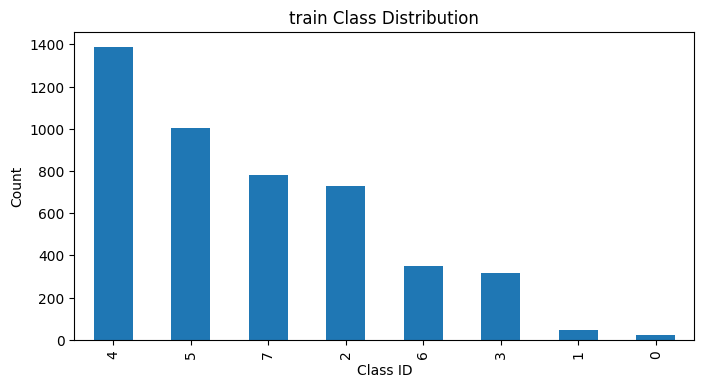

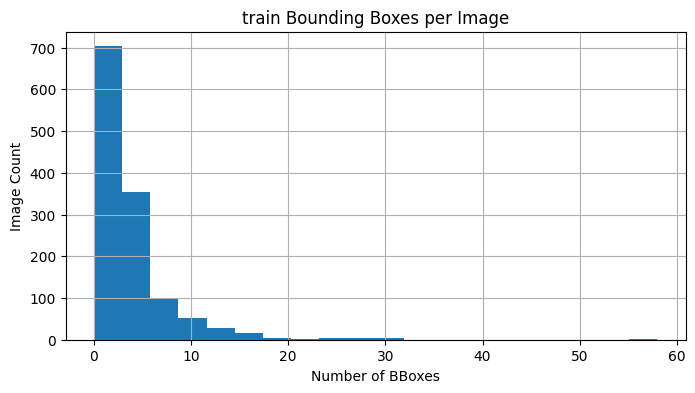

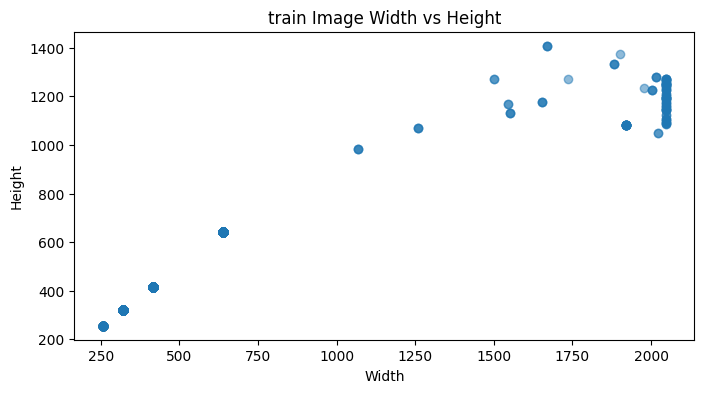


--- VALID SPLIT ---
Number of images: 158
Number of labels: 158
Class distribution:
4    184
5    144
7     84
2     82
3     38
6     15
1      4
0      1
Name: count, dtype: int64


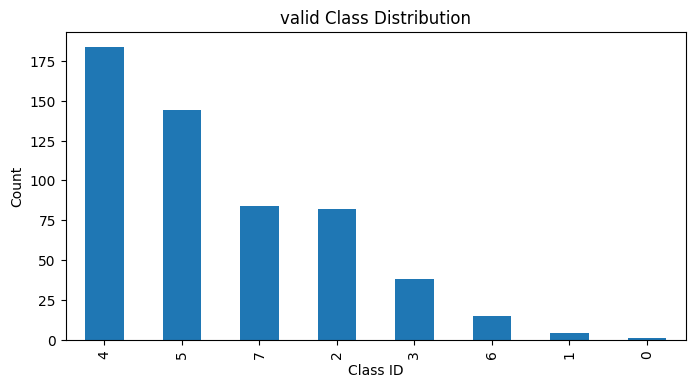

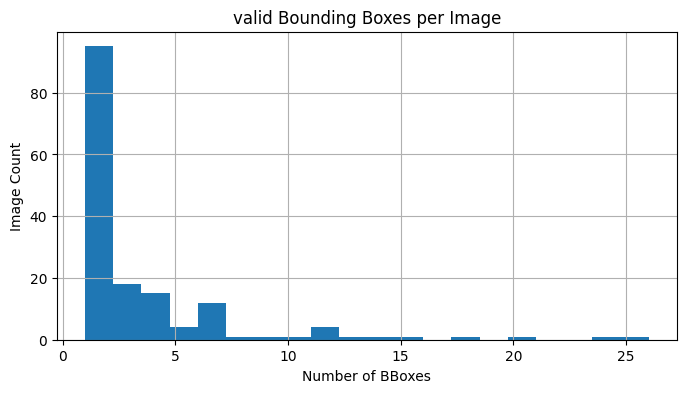

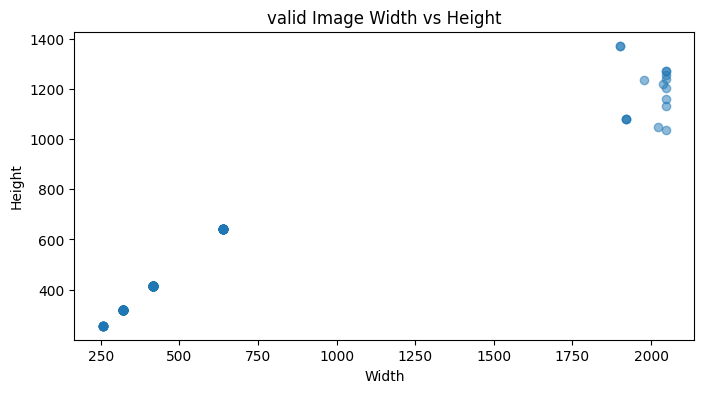


--- TEST SPLIT ---
Number of images: 158
Number of labels: 158
Class distribution:
4    152
7    121
5    121
6     85
2     82
3     37
1      7
0      3
Name: count, dtype: int64


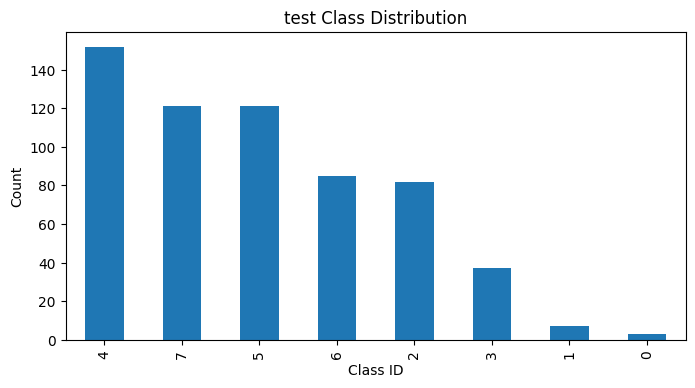

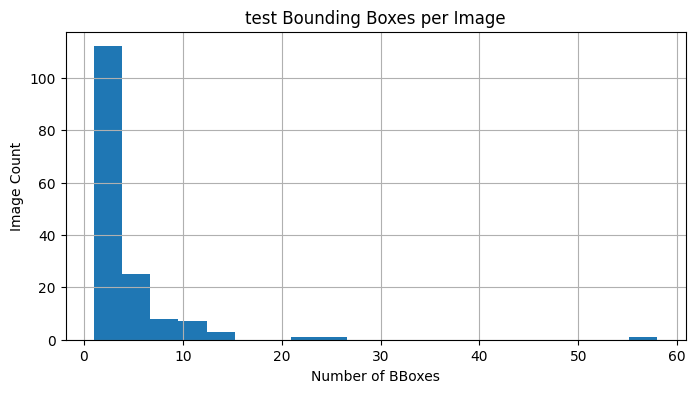

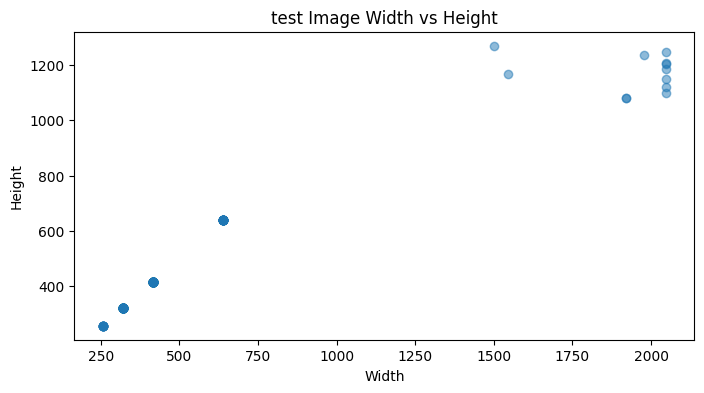

ValueError: too many values to unpack (expected 5)

In [18]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import random

# Paths to your dataset splits
splits = ["train", "valid", "test"]

# Dictionary to store EDA results
eda_info = {}

for split in splits:
    image_path = f"dataset/{split}/images"
    label_path = f"dataset/{split}/labels"
    
    images = glob.glob(os.path.join(image_path, "*"))
    labels = glob.glob(os.path.join(label_path, "*"))
    
    print(f"\n--- {split.upper()} SPLIT ---")
    print(f"Number of images: {len(images)}")
    print(f"Number of labels: {len(labels)}")
    
    # Store basic info
    eda_info[split] = {
        "num_images": len(images),
        "num_labels": len(labels),
        "classes": [],
        "bbox_count_per_image": [],
        "image_shapes": []
    }
    
    all_classes = []
    bbox_counts = []
    img_shapes = []
    
    for label_file in labels:
        with open(label_file, 'r') as f:
            lines = f.readlines()
        bbox_counts.append(len(lines))
        classes = [int(line.split()[0]) for line in lines]  # first number = class id
        all_classes.extend(classes)
        
        # Get image shape
        img_file = os.path.join(image_path, os.path.basename(label_file).replace(".txt", ".jpg"))
        if not os.path.exists(img_file):
            img_file = os.path.join(image_path, os.path.basename(label_file).replace(".txt", ".png"))
        img = cv2.imread(img_file)
        if img is not None:
            img_shapes.append(img.shape[:2])  # height, width
    
    eda_info[split]["classes"] = all_classes
    eda_info[split]["bbox_count_per_image"] = bbox_counts
    eda_info[split]["image_shapes"] = img_shapes
    
    # Show class distribution
    class_counts = pd.Series(all_classes).value_counts()
    print("Class distribution:")
    print(class_counts)
    
    # Plot class distribution
    plt.figure(figsize=(8,4))
    class_counts.plot(kind="bar")
    plt.title(f"{split} Class Distribution")
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.show()
    
    # Plot bounding boxes per image
    plt.figure(figsize=(8,4))
    pd.Series(bbox_counts).hist(bins=20)
    plt.title(f"{split} Bounding Boxes per Image")
    plt.xlabel("Number of BBoxes")
    plt.ylabel("Image Count")
    plt.show()
    
    # Plot image sizes
    heights, widths = zip(*img_shapes)
    plt.figure(figsize=(8,4))
    plt.scatter(widths, heights, alpha=0.5)
    plt.title(f"{split} Image Width vs Height")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()

# Visualize some random images with bounding boxes
def visualize_samples(split="train", n=5):
    image_path = f"dataset/{split}/images"
    label_path = f"dataset/{split}/labels"
    images = glob.glob(os.path.join(image_path, "*"))
    sample_imgs = random.sample(images, n)
    
    for img_file in sample_imgs:
        img = cv2.imread(img_file)
        h, w = img.shape[:2]
        label_file = os.path.join(label_path, os.path.basename(img_file).replace(".jpg", ".txt").replace(".png", ".txt"))
        
        with open(label_file, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            cls, x_center, y_center, bbox_w, bbox_h = map(float, parts)
            # Convert normalized YOLO coords to absolute pixels
            x1 = int((x_center - bbox_w/2) * w)
            y1 = int((y_center - bbox_h/2) * h)
            x2 = int((x_center + bbox_w/2) * w)
            y2 = int((y_center + bbox_h/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(img, str(int(cls)), (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{split} Sample with BBoxes")
        plt.axis("off")
        plt.show()

# Example: visualize 5 train images
visualize_samples("train", n=5)

In [20]:
import os

# Update these paths to your actual label folders
label_paths = [
    'dataset/train/labels',
    'dataset/valid/labels',
    'dataset/test/labels'
]

for folder in label_paths:
    if not os.path.exists(folder):
        print(f"Skipping {folder}, path not found.")
        continue
        
    for filename in os.listdir(folder):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder, filename)
            
            with open(file_path, 'r') as f:
                lines = f.readlines()
            
            new_lines = []
            for line in lines:
                parts = line.split()
                if len(parts) > 0:
                    # Force the first number (Class ID) to be 0
                    parts[0] = '0'
                    new_lines.append(" ".join(parts) + "\n")
            
            with open(file_path, 'w') as f:
                f.writelines(new_lines)

print("Done! All labels consolidated to Class 0.")

Done! All labels consolidated to Class 0.
